In [50]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import plot_importance
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import GridSearchCV


import seaborn as sns
from xgboost import XGBRegressor

In [51]:
import warnings
warnings.filterwarnings("ignore")

## Load the dataset

In [52]:
train_file_path = "house-prices-advanced-regression-techniques/train.csv"
dataset_df = pd.read_csv(train_file_path)
print("Full train dataset shape is {}".format(dataset_df.shape))

Full train dataset shape is (1460, 81)


The data is composed of 81 columns and 1460 entries. We can see all 81 dimensions of our dataset by printing out the first 3 entries using the following code:

In [53]:
dataset_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


There are 79 feature columns. Using these features your model has to predict the house sale price indicated by the label column named SalePrice.

We will drop the Id column as it is not necessary for model training.

In [54]:
dataset_df = dataset_df.drop('Id', axis=1)
dataset_df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [55]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [56]:
dataset_df.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [57]:
def missing_percentage(df):
    total = df.isnull().sum().sort_values(ascending = False)[df.isnull().sum().sort_values(ascending = False) != 0]
    percentage = round(df.isnull().sum().sort_values(ascending=False)*100 / len(df),2)[df.isnull().sum().sort_values(ascending=False)*100 / len(df) != 0]
    return pd.concat([total,percentage],axis = 1,keys=['Total','Percentage'])

missing_percentage(dataset_df)

,Total,Percentage
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageCond,81,5.55
GarageType,81,5.55


## House Price Distribution

Now let us take a look at how the house prices are distributed.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


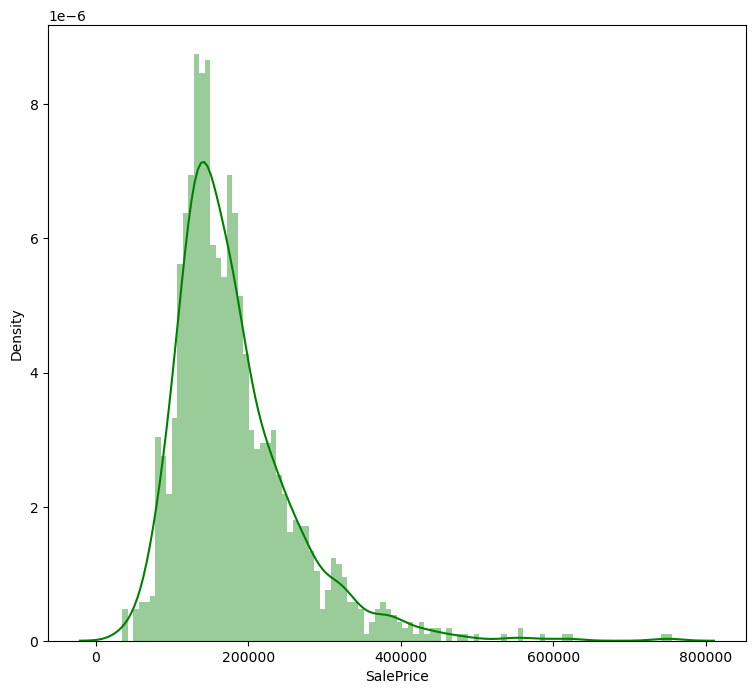

In [58]:
print(dataset_df['SalePrice'].describe())
plt.figure(figsize=(9, 8))
sns.distplot(dataset_df['SalePrice'], color='g', bins=100, hist_kws={'alpha': 0.4});

## Numerical data distribution

We will now take a look at how the numerical features are distributed. In order to do this, let us first list all the types of data from our dataset and select only the numerical ones.

In [59]:
list(set(dataset_df.dtypes.tolist()))

[dtype('float64'), dtype('O'), dtype('int64')]

In [60]:
df_num = dataset_df.select_dtypes(include = ['float64', 'int64'])
df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000


Now let us plot the distribution for all the numerical features.

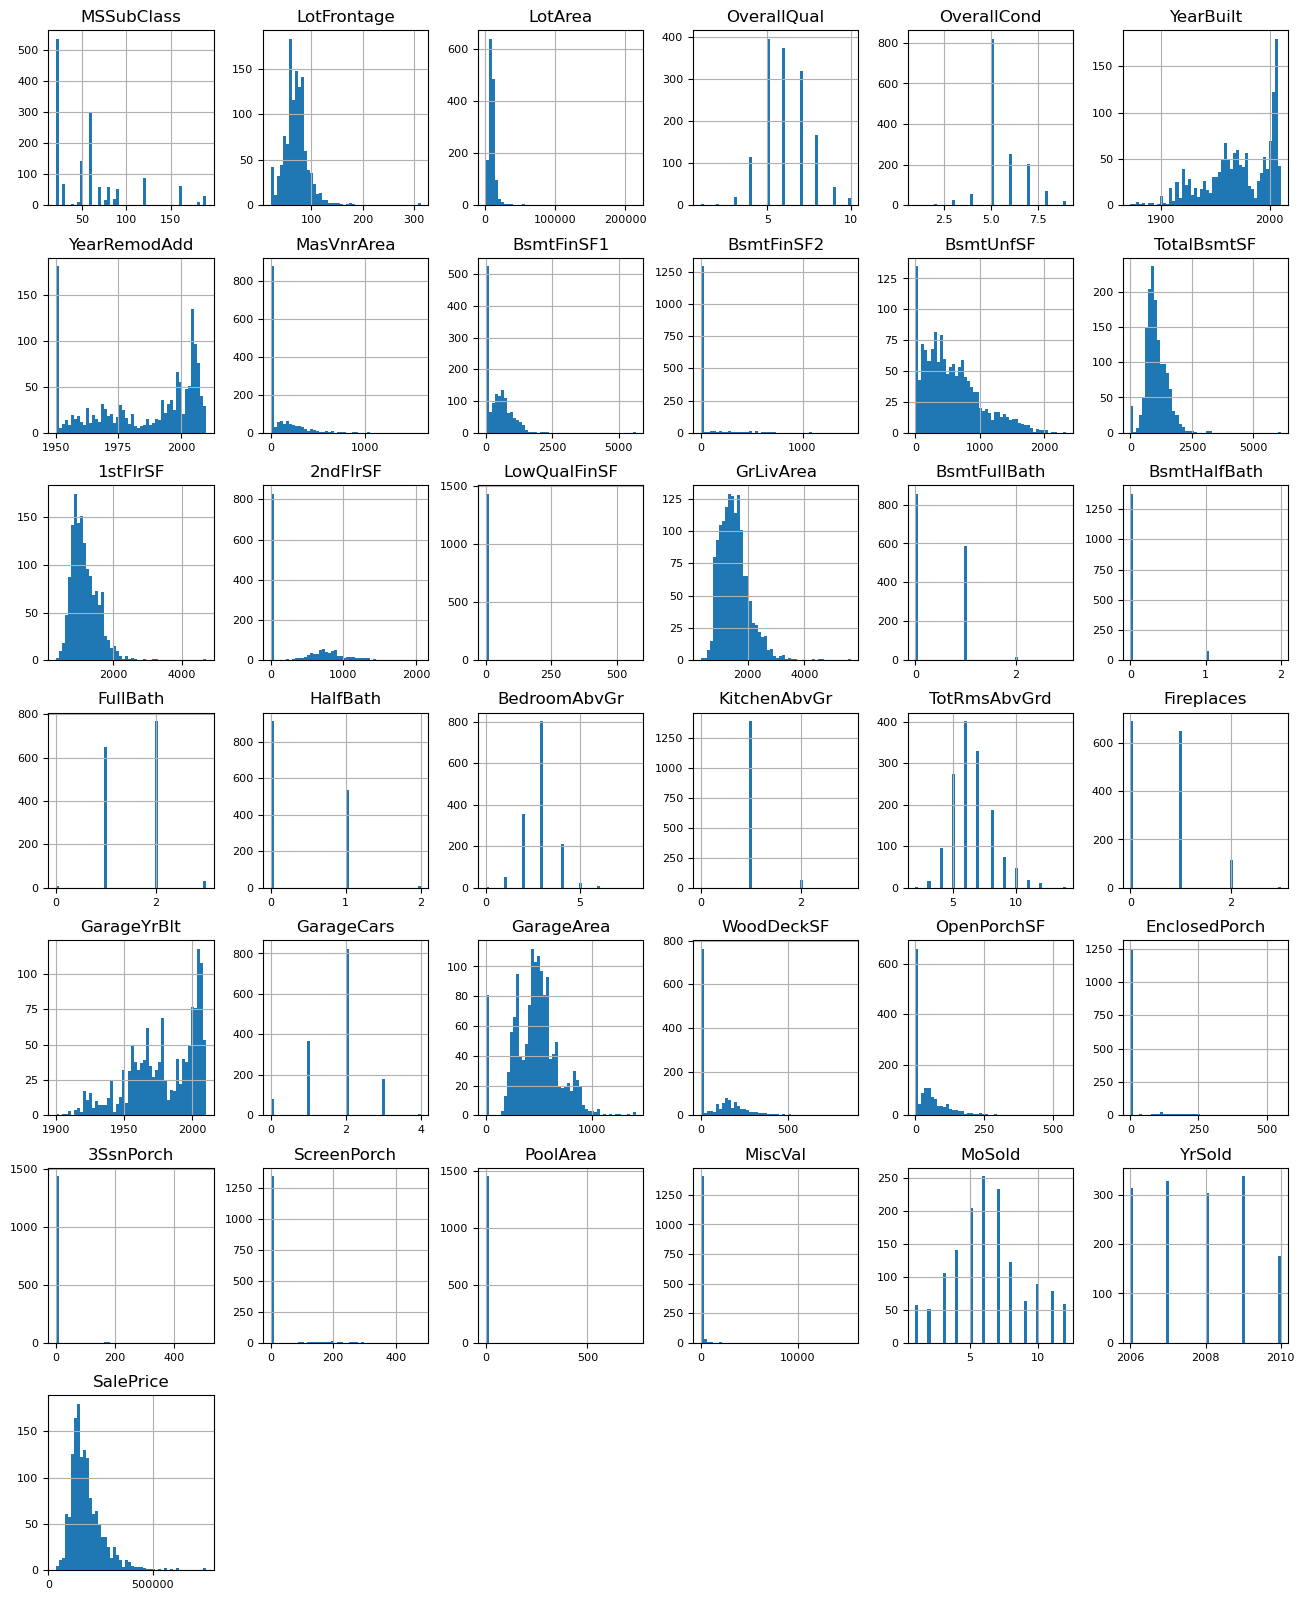

In [61]:
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

## Prepare the dataset

Turn the 'GarageYrBlt' column into a categorical one with options 1/0, where 1 - there is a availability of a garage, 0 - no garage.
Empty values of 'MasVnrArea' will be replaced by the average value of the column.
In all other cases, due to the small number of gaps, replace the empty values with 0 by calling the *df.fillna(0)*:

In [62]:
num_col = []
name_col = []

types_dict = dataset_df.columns.to_series().groupby(dataset_df.dtypes).groups
{key.name: vol for key, vol in types_dict.items()}

for key, vol in types_dict.items():
    if key == 'int' or key == 'float':
        for col in range(len(vol)):
            num_col.append(vol[col])
    else:
        for col in range(len(vol)):
            name_col.append(vol[col])

In [63]:
dataset_df.GarageYrBlt.loc[~dataset_df.GarageYrBlt.isnull()] = 1
dataset_df.GarageYrBlt.loc[dataset_df.GarageYrBlt.isnull()] = 0

dataset_df.MasVnrArea = dataset_df.MasVnrArea.fillna(dataset_df.MasVnrArea.mean())
dataset_df[num_col] = dataset_df[num_col].fillna(0)

Since, judging by the description, empty values mean the absence of a feature, so we will just replace the empty values for all columns with 'No':

In [64]:
dataset_df[name_col] = dataset_df[name_col].fillna('No')

split the dataset into training and testing datasets:

In [65]:
data = dataset_df

# Separate features and target
y = data.SalePrice
X = data.drop(['SalePrice'], axis=1)

# Convert categorical columns to the 'category' dtype
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    X[col] = X[col].astype('category')  

# Split the data into training and testing sets
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.25, random_state=42)

### XGB

In [66]:
xgb_model = XGBRegressor(tree_method="hist", enable_categorical=True, use_label_encoder=False)

# Set up the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Perform GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=3,
                           verbose=1,
                           n_jobs=-1)
grid_search.fit(train_X, train_y)

# Get the best model
best_model = grid_search.best_estimator_

# Make predictions with the best model
predictions = best_model.predict(test_X)

# Evaluate the model
mae = mean_absolute_error(test_y, predictions)
rmse = np.sqrt(mean_squared_error(test_y, predictions))

print("Best Parameters:", grid_search.best_params_)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Fitting 3 folds for each of 108 candidates, totalling 324 fits


/Users/yitonglin/.local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [18:31:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/yitonglin/.local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [18:31:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/yitonglin/.local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [18:31:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/yitonglin/.local/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [18:31:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Use

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Mean Absolute Error (MAE): 14322.73
Root Mean Squared Error (RMSE): 23006.96


<Figure size 2000x2000 with 0 Axes>

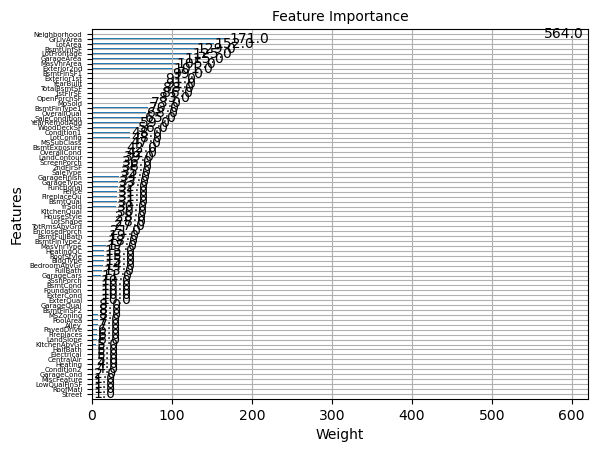

In [67]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Plot feature importance
plt.figure(figsize=(20, 20))
ax = plot_importance(best_model, importance_type="weight", xlabel="Weight", ylabel="Features")
plt.title("Feature Importance", fontsize=10)

# Adjust font size of labels
ax.set_yticklabels(ax.get_yticklabels(), fontsize=5)

plt.show()

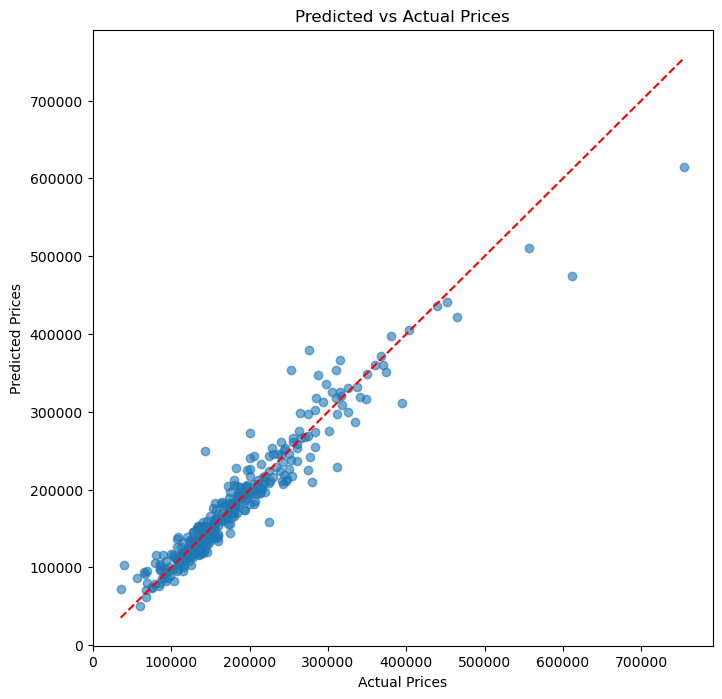

In [68]:
# Predicted vs Actual
plt.figure(figsize=(8, 8))
plt.scatter(test_y, predictions, alpha=0.6)
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], color='red', linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual Prices")
plt.show()

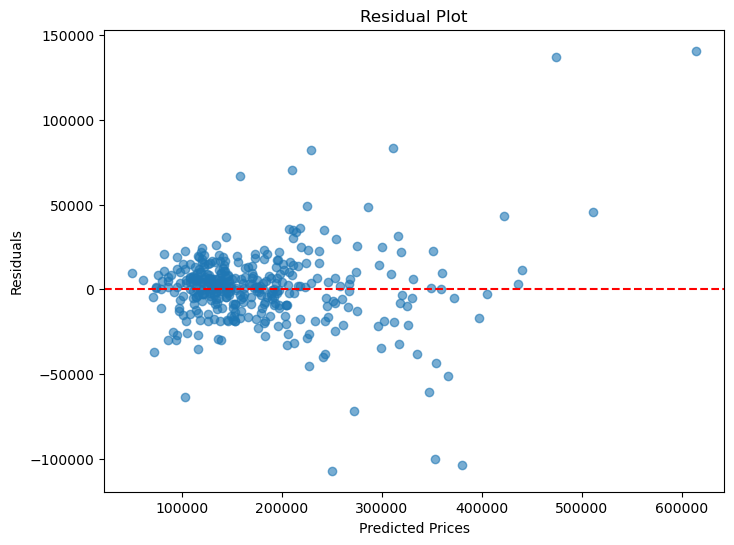

In [69]:
# Residuals
residuals = test_y - predictions

plt.figure(figsize=(8, 6))
plt.scatter(predictions, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### MLP

split the categorical columns into dummy variables

standardize all columns except cost, including dummy variables and columns where we changed the value to 0/1

In [70]:
data = dataset_df
df = dataset_df

categorical_cols = data.select_dtypes(include=['object']).columns
numerical_cols = data.select_dtypes(exclude=['object']).columns.drop('SalePrice')

correlation matrix of numerical factors to find and exclude duplicate indicators with high correlation

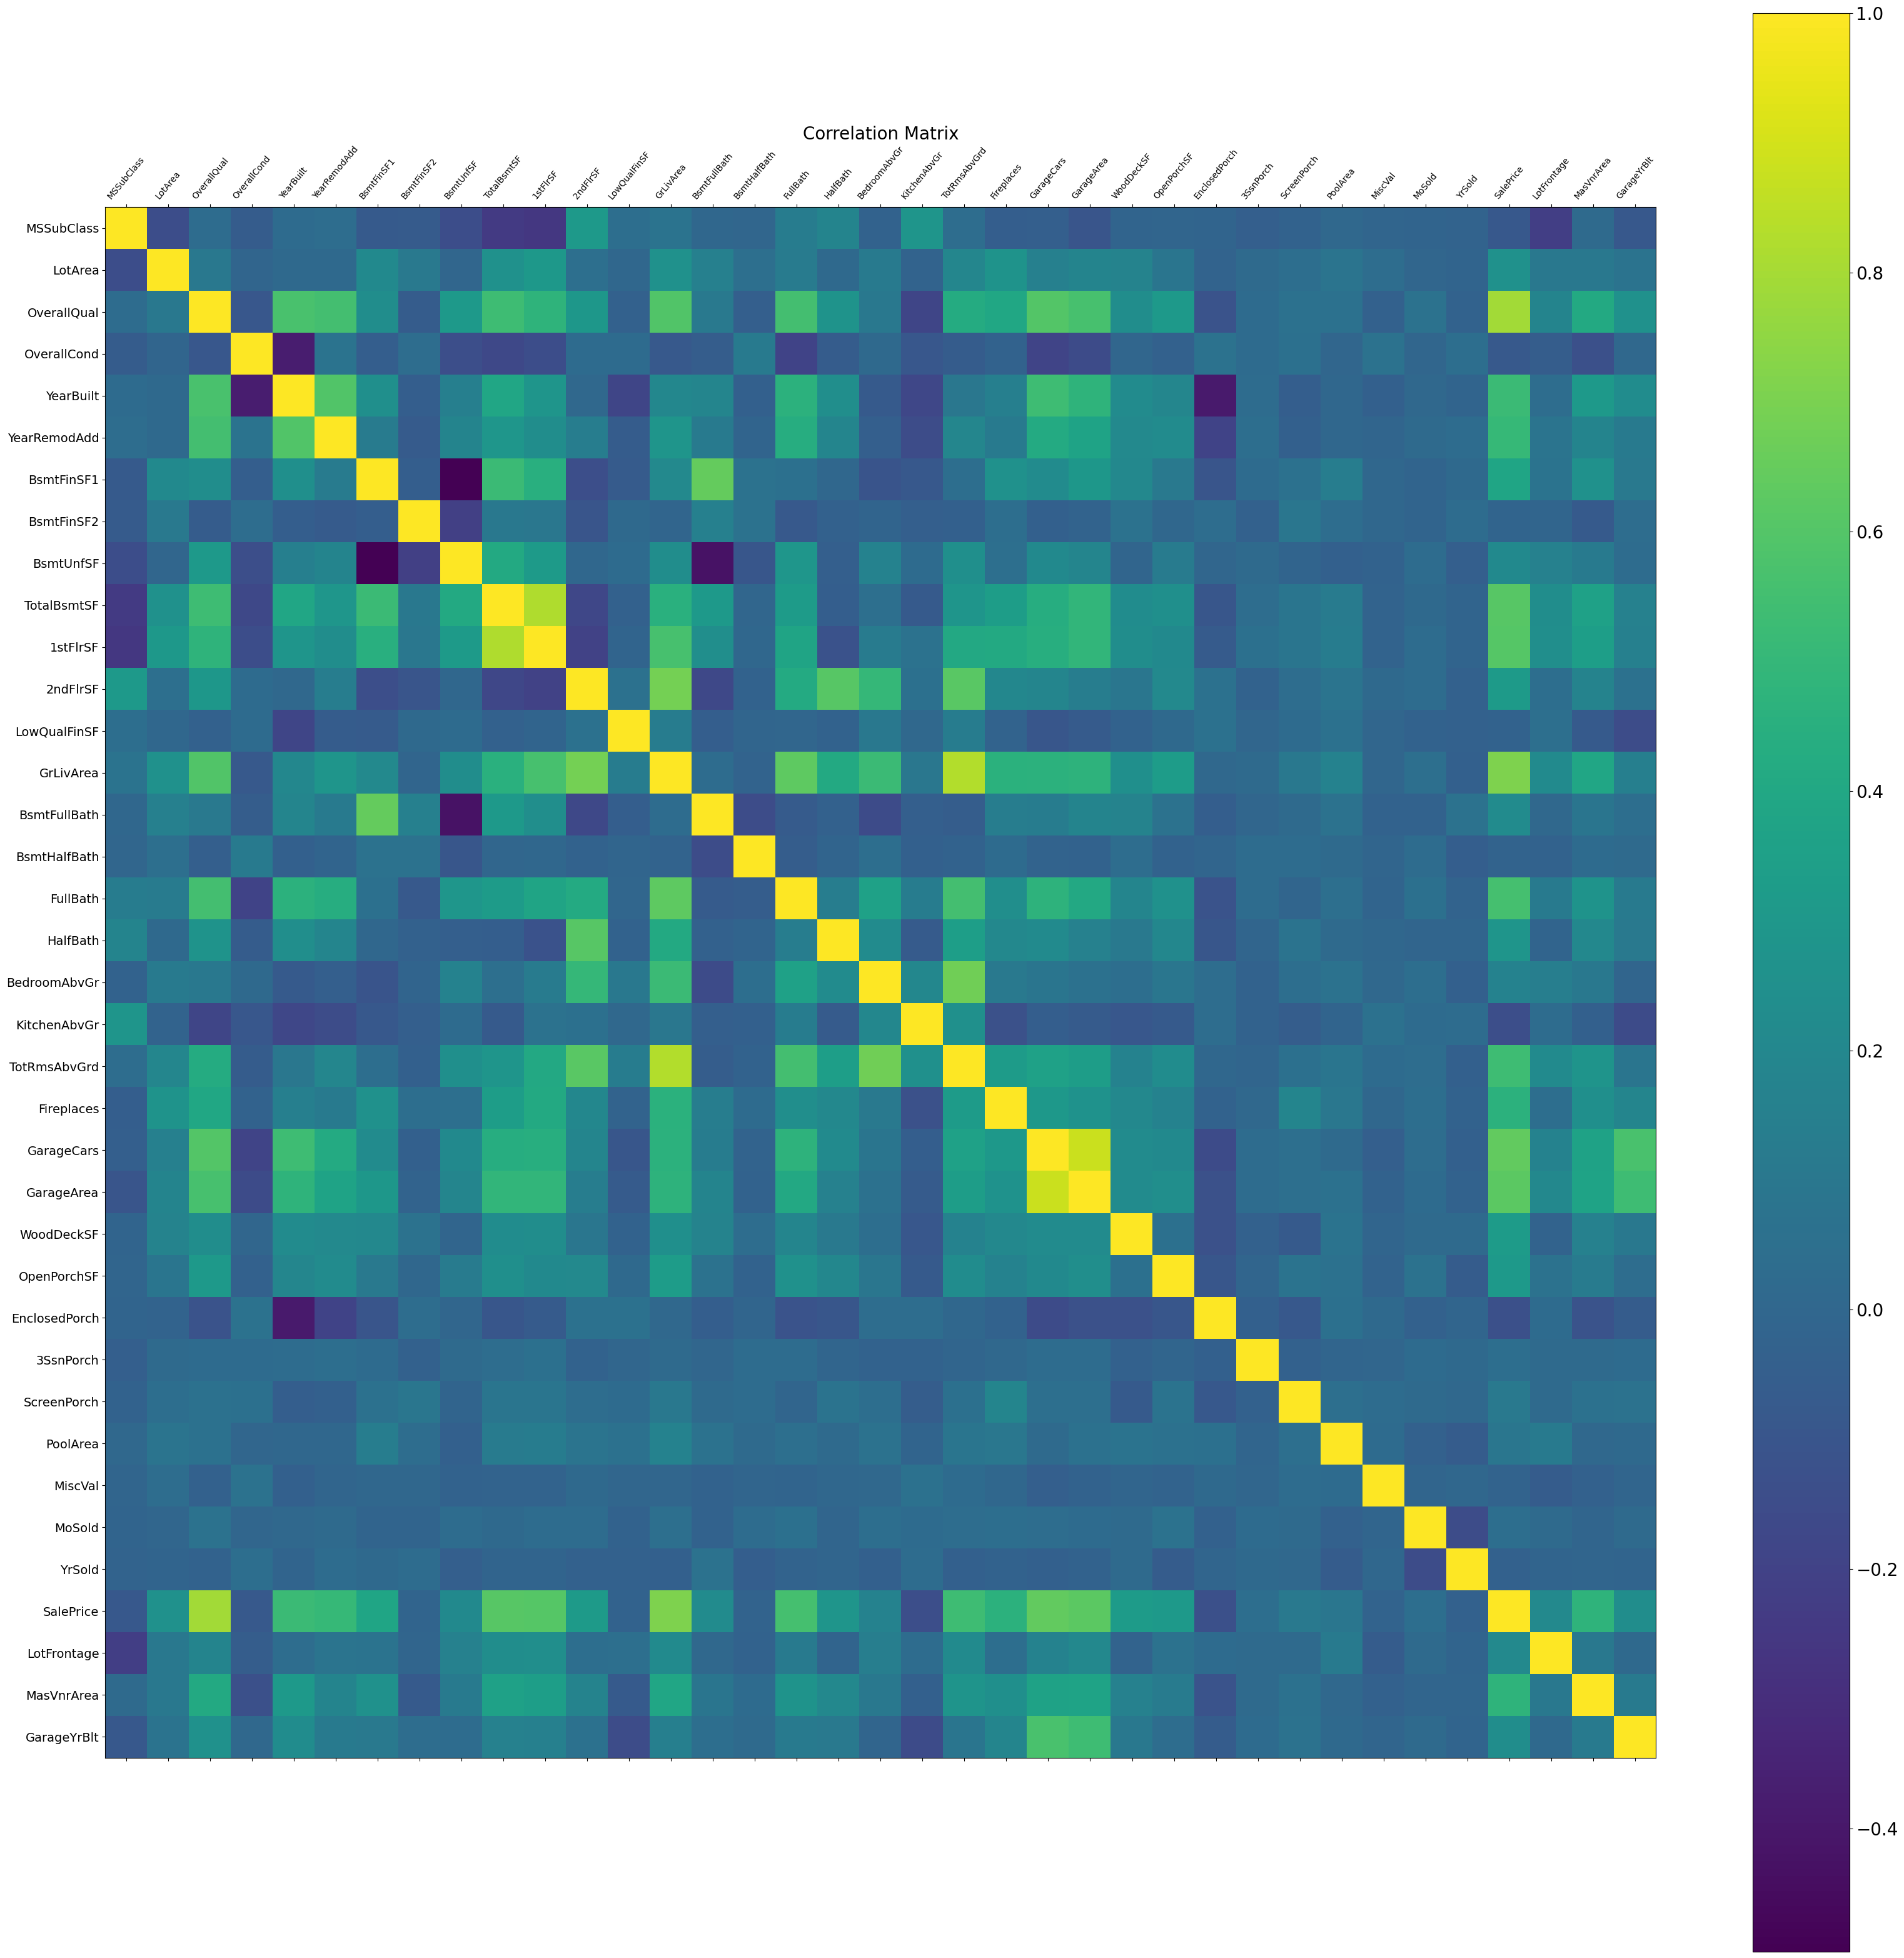

In [71]:
from matplotlib import pyplot as plt 

f = plt.figure(figsize=(40, 40))
plt.matshow(df[num_col].corr(), fignum=f.number)
plt.xticks(range(df[num_col].select_dtypes(['number']).shape[1]), df[num_col].select_dtypes(['number']).columns, fontsize=10, rotation=50)
plt.yticks(range(df[num_col].select_dtypes(['number']).shape[1]), df[num_col].select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize = 20)
plt.title('Correlation Matrix', fontsize=20);

drop indicators that have a high direct and inverse correlation

In [72]:
df = df.drop(['BsmtFinSF1'], axis=1)
df = df.drop(['BsmtFinSF2'], axis=1)
df = df.drop(['BsmtFullBath'], axis=1)
df = df.drop(['GarageCars'], axis=1)
df = df.drop(['2ndFlrSF'], axis=1)

new cor:

In [73]:
types_dict = df.columns.to_series().groupby(df.dtypes).groups

num_col = []

for key, vol in types_dict.items():
    if key == 'int' or key == 'float':
        for col in range(len(vol)):
            num_col.append(vol[col])

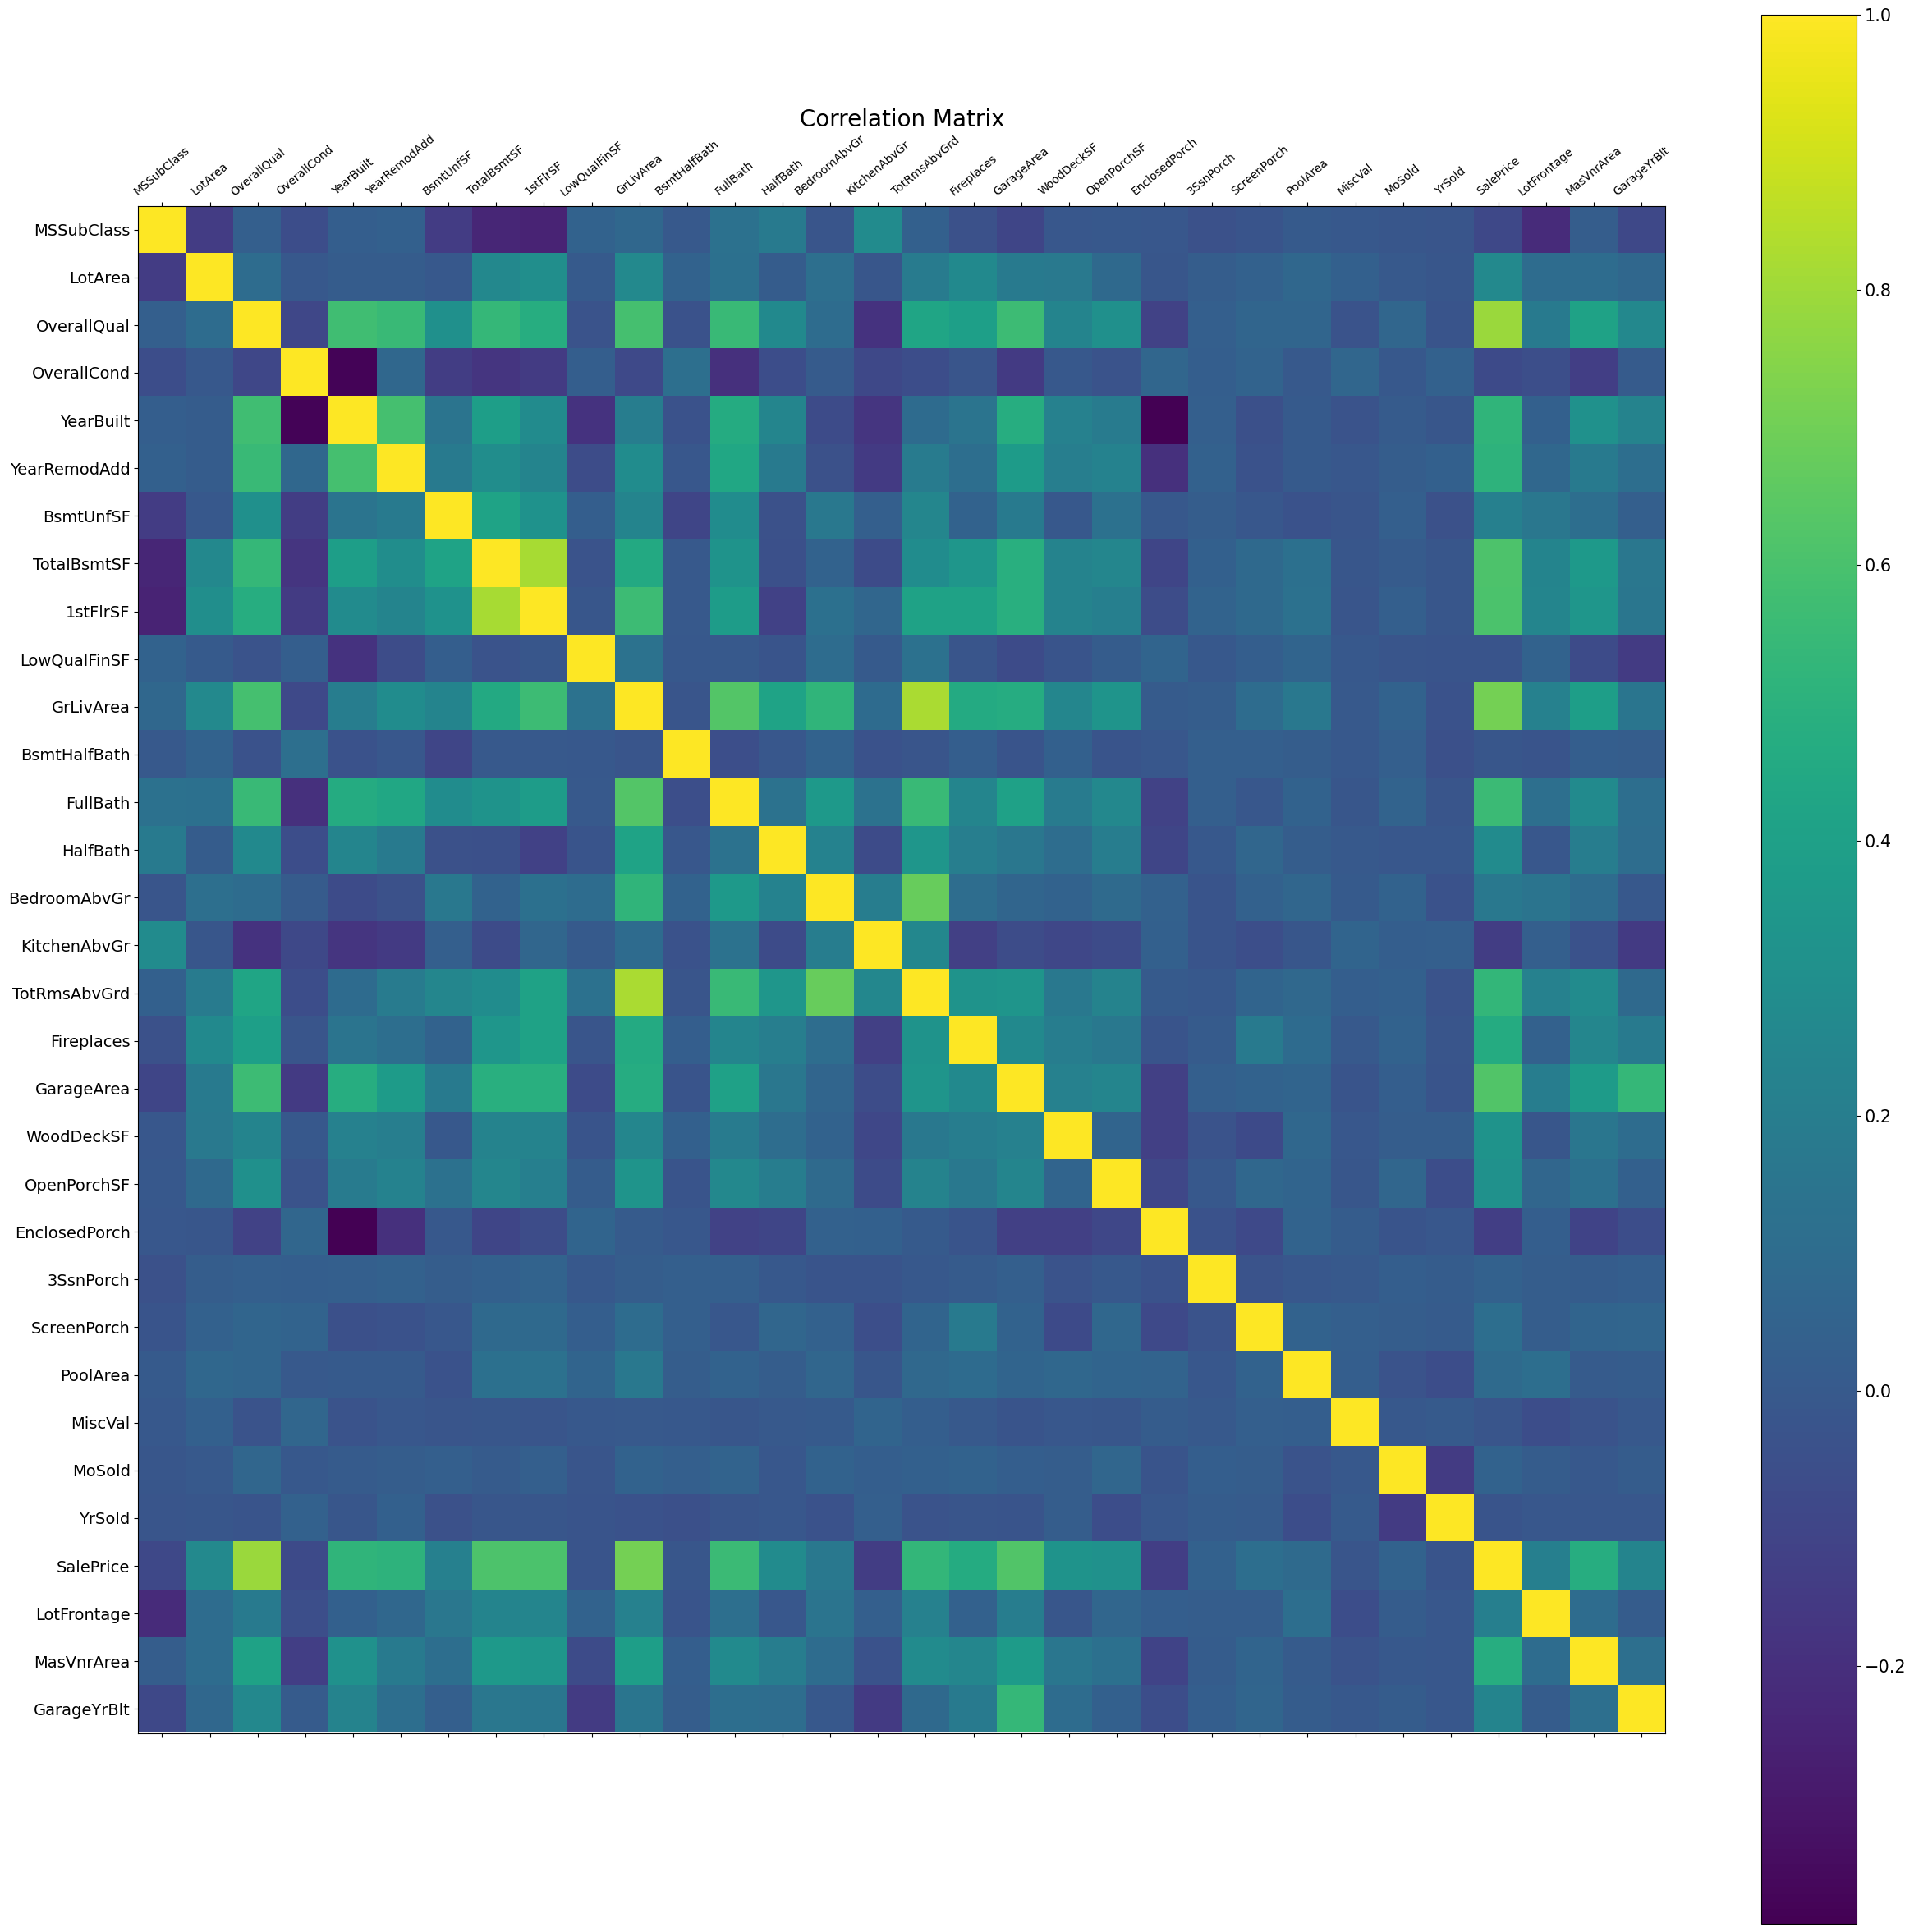

In [74]:
f = plt.figure(figsize=(30, 30))
plt.matshow(df[num_col].corr(), fignum=f.number)
plt.xticks(range(df[num_col].select_dtypes(['number']).shape[1]), df[num_col].select_dtypes(['number']).columns, fontsize=10, rotation=40)
plt.yticks(range(df[num_col].select_dtypes(['number']).shape[1]), df[num_col].select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize = 15)
plt.title('Correlation Matrix', fontsize = 20);

In [75]:
df[num_col].iloc[:,:].describe().applymap(lambda x: f"{x:0.3f}")

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtUnfSF,TotalBsmtSF,1stFlrSF,LowQualFinSF,...,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,LotFrontage,MasVnrArea,GarageYrBlt
count,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,...,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000
mean,56.897,10516.828,6.099,5.575,1971.268,1984.866,567.240,1057.429,1162.627,5.845,...,3.410,15.061,2.759,43.489,6.322,2007.816,180921.196,57.623,103.685,0.945
std,42.301,9981.265,1.383,1.113,30.203,20.645,441.867,438.705,386.588,48.623,...,29.317,55.757,40.177,496.123,2.704,1.328,79442.503,34.664,180.569,0.229
min,20.000,1300.000,1.000,1.000,1872.000,1950.000,0.000,0.000,334.000,0.000,...,0.000,0.000,0.000,0.000,1.000,2006.000,34900.000,0.000,0.000,0.000
25%,20.000,7553.500,5.000,5.000,1954.000,1967.000,223.000,795.750,882.000,0.000,...,0.000,0.000,0.000,0.000,5.000,2007.000,129975.000,42.000,0.000,1.000
50%,50.000,9478.500,6.000,5.000,1973.000,1994.000,477.500,991.500,1087.000,0.000,...,0.000,0.000,0.000,0.000,6.000,2008.000,163000.000,63.000,0.000,1.000
75%,70.000,11601.500,7.000,6.000,2000.000,2004.000,808.000,1298.250,1391.250,0.000,...,0.000,0.000,0.000,0.000,8.000,2009.000,214000.000,79.000,164.250,1.000
max,190.000,215245.000,10.000,9.000,2010.000,2010.000,2336.000,6110.000,4692.000,572.000,...,508.000,480.000,738.000,15500.000,12.000,2010.000,755000.000,313.000,1600.000,1.000


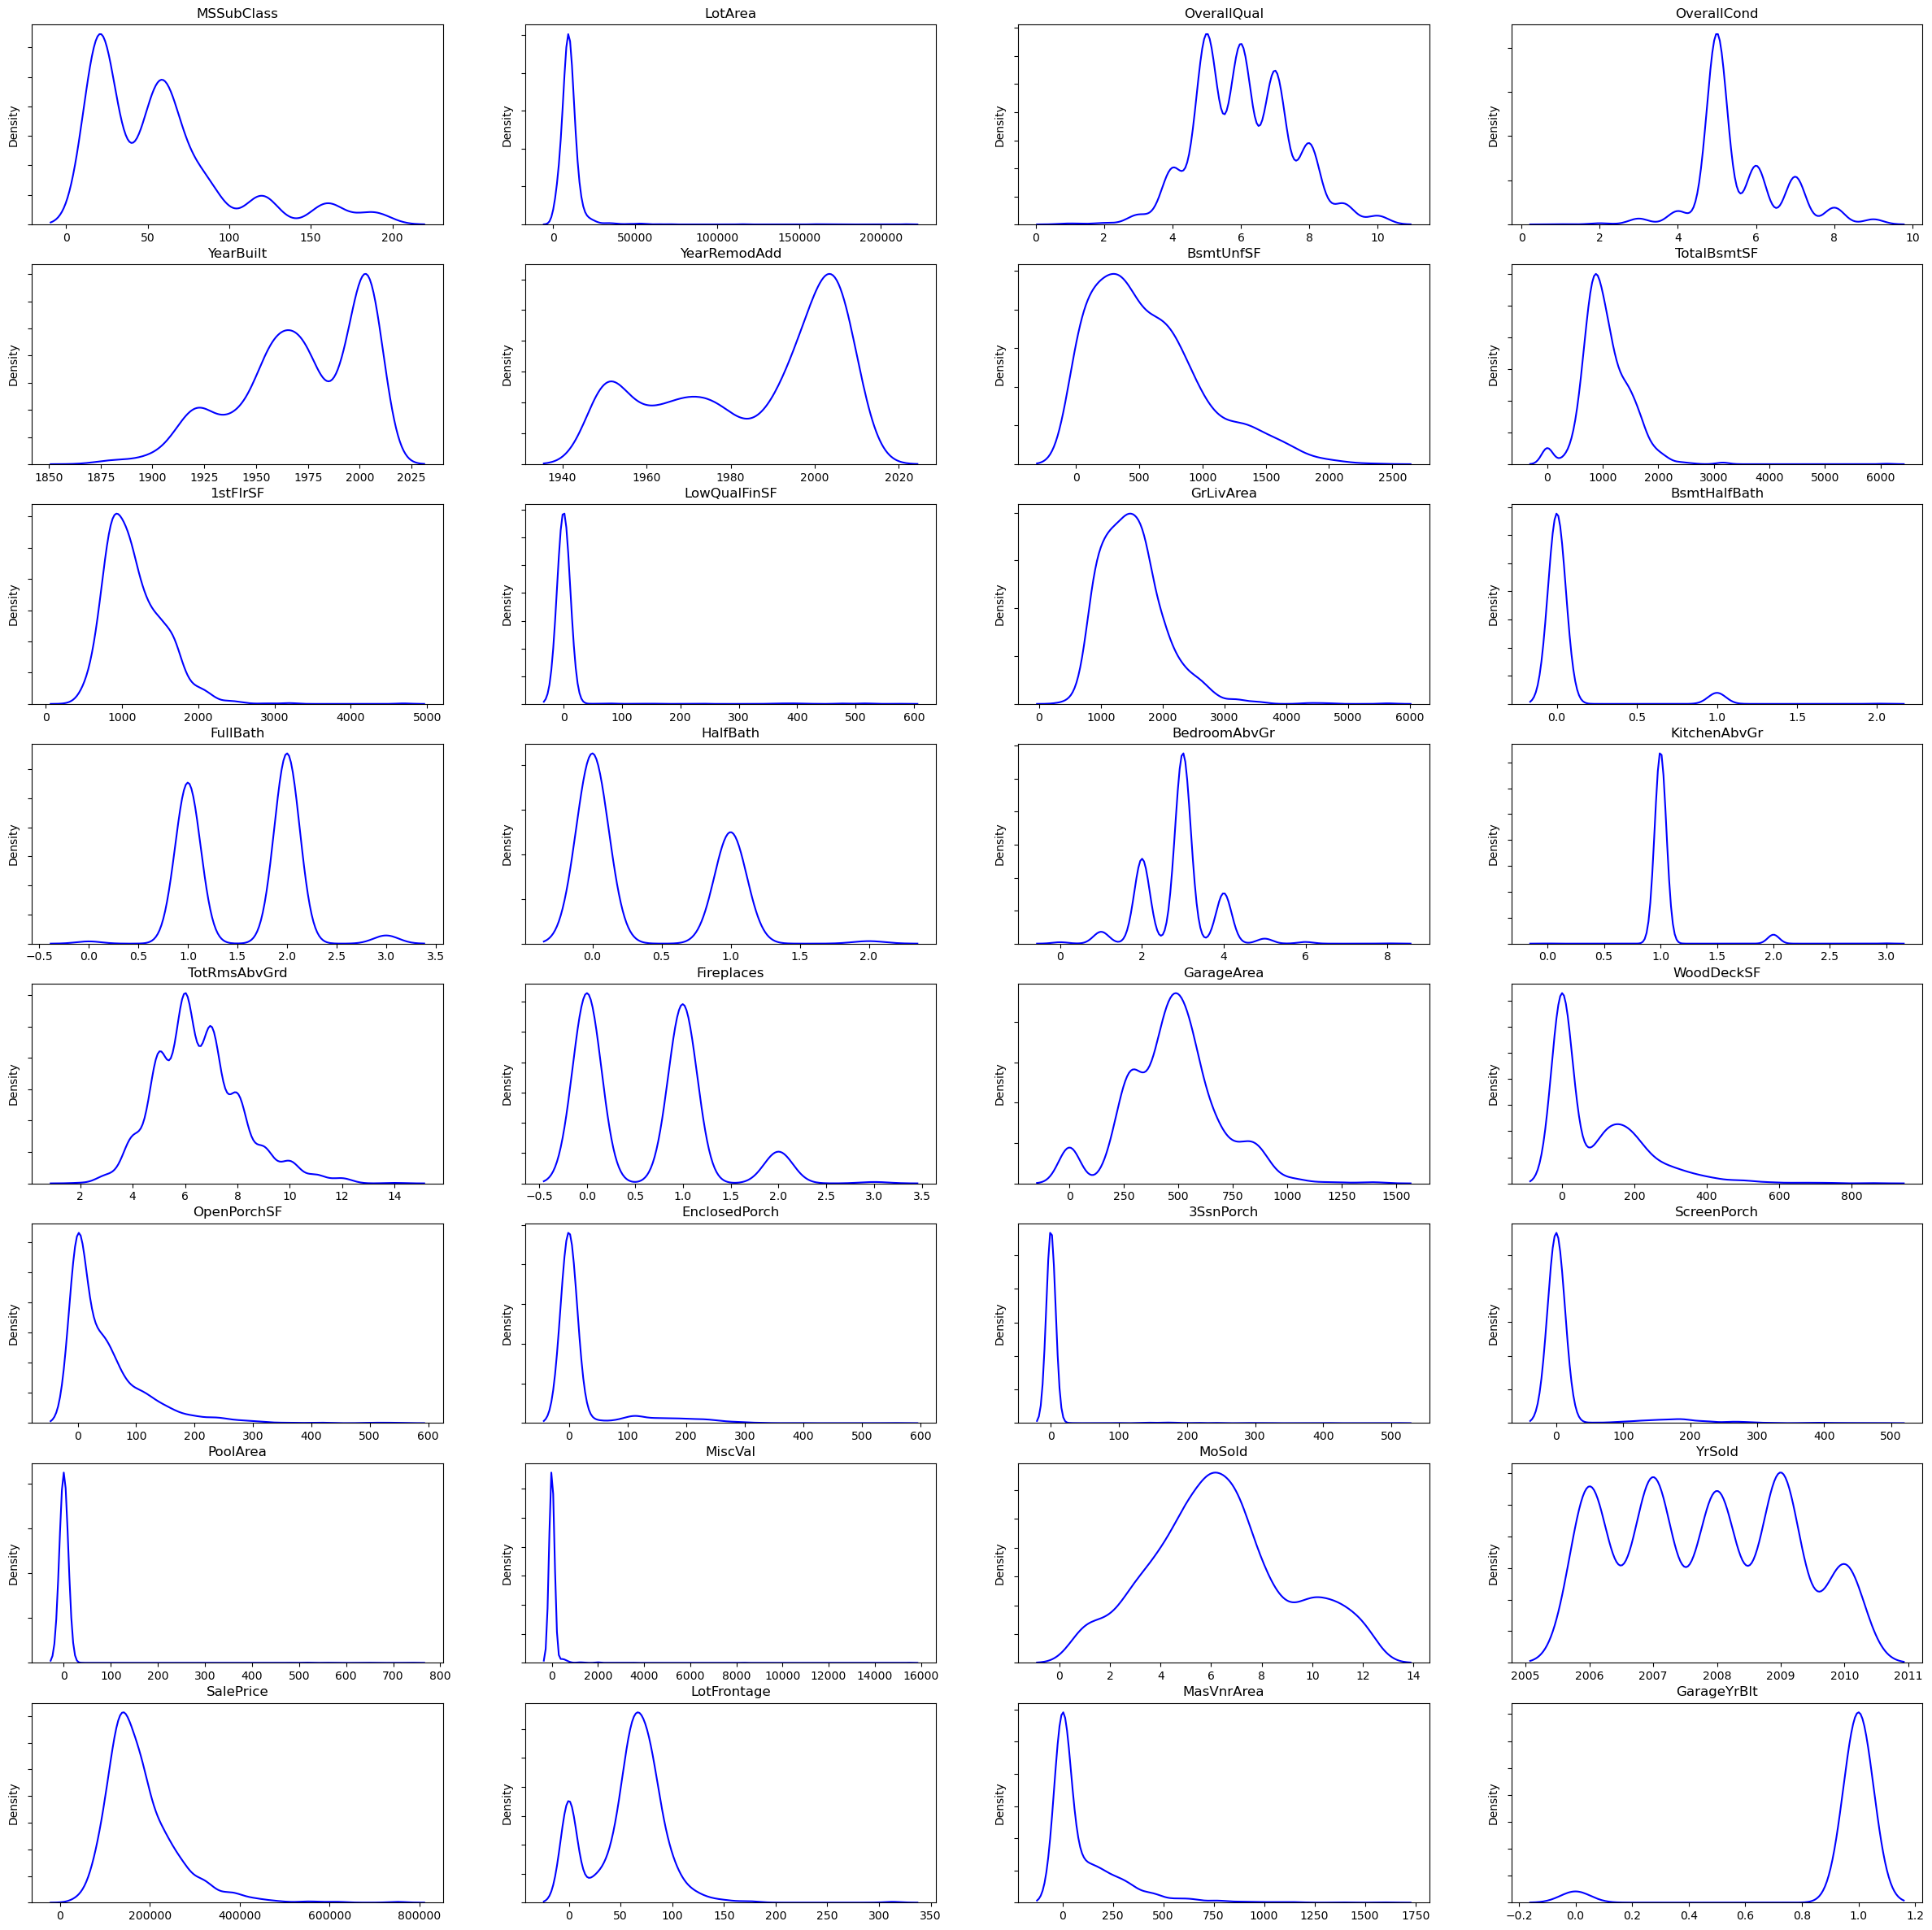

In [76]:
plt.subplots(8, 4, figsize = (30, 30))

# Plot a density plot for each variable
for idx, col in enumerate(num_col):
    ax = plt.subplot(8, 4, idx + 1)
    ax.yaxis.set_ticklabels([])
    sns.distplot(df[col], hist=False, axlabel= False, 
    kde_kws={'linestyle':'-', 'color':'blue', 'label':"No Diabetes"})
    ax.set_title(col)

plt.show()

Look at suspicious outliers and exclude them if they are included only in the training set:

In [77]:
num_col_ = ['LotArea', '1stFlrSF', 'LowQualFinSF', 'GrLivArea', 
 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
 'PoolArea', 'MiscVal', 'LotFrontage', 'MasVnrArea', 'TotalBsmtSF', 'SalePrice']

In [78]:
index_drop = np.array([])

index_drop = np.unique(np.concatenate((
    np.concatenate((
        np.concatenate((
            np.concatenate((
                np.concatenate((
                    np.concatenate((
                        np.concatenate((
                            np.concatenate((
                                np.concatenate((index_drop, df[df['LotArea'] > 30000].index.values)),
                                df[df['1stFlrSF'] > 3000].index.values)),
                            df[df['GrLivArea'] > 4000].index.values)),
                        df[df['WoodDeckSF'] > 600].index.values)),
                    df[df['LotFrontage'] > 200].index.values)),
                df[df['OpenPorchSF'] > 400].index.values)),
            df[df['MasVnrArea'] > 1000].index.values)),
        df[df['TotalBsmtSF'] > 3000].index.values)), 
    df[df['SalePrice'] > 500000].index.values)))

index_drop = index_drop[index_drop < np.max(train_X.index)]
df = df.drop(index = index_drop)

Similarly to the 'GarageYrBlt' column, we will convert the remaining 'suspicious' indicators into a categorical type with options 1/0, where 1 is a value greater than 1, 0 - otherwise:

In [79]:
for col in ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
           'ScreenPorch', 'PoolArea', 'MiscVal', 'LowQualFinSF']:
    
    df[col].loc[df[col] > 1] = 1
    df[col].loc[df[col] < 1] = 0

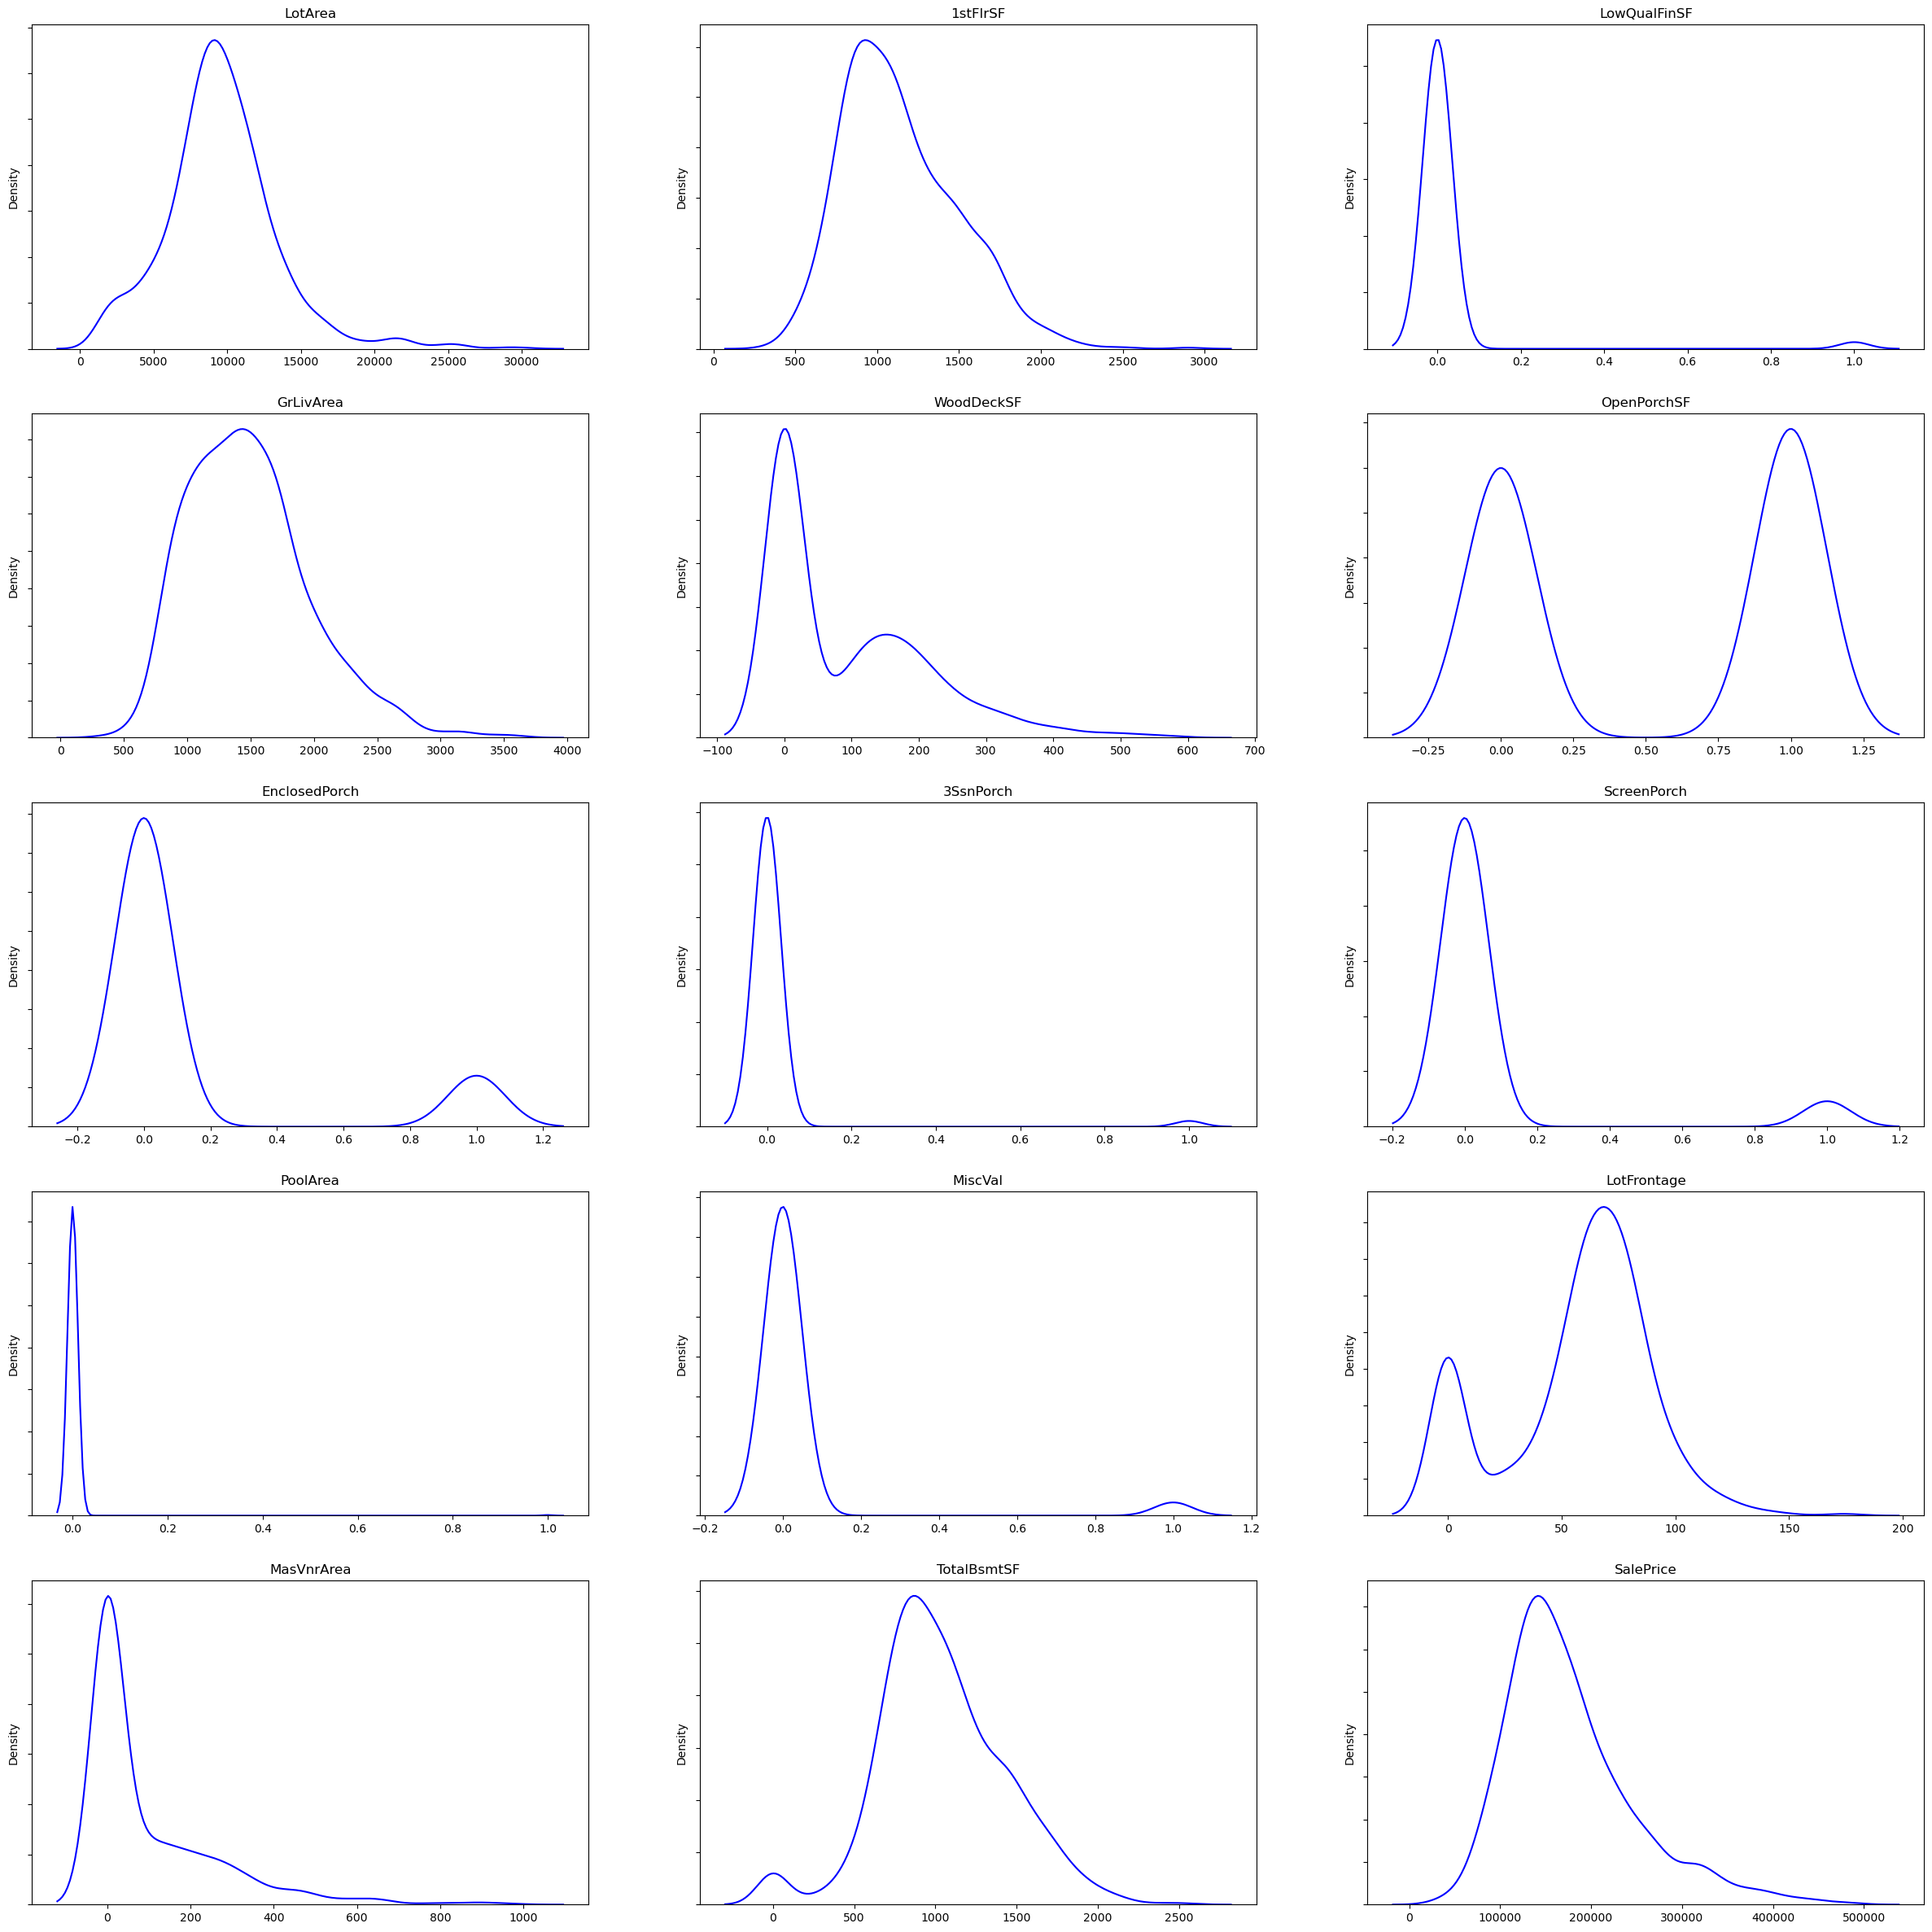

In [80]:
plt.subplots(5, 3, figsize = (30, 30))

# Plot a density plot for each variable
for idx, col in enumerate(num_col_):
    ax = plt.subplot(5, 3, idx + 1)
    ax.yaxis.set_ticklabels([])
    sns.distplot(df.iloc[:len(train_X) - len(index_drop)][col], hist=False, axlabel= False, 
    kde_kws={'linestyle':'-', 'color':'blue', 'label':"No Diabetes"})
    ax.set_title(col)

plt.show()

In [81]:
new_name_columns = pd.get_dummies(df[name_col], columns = name_col).columns
df = pd.get_dummies(data = df, columns=name_col)

In [82]:
df_scaled_train = df.iloc[:(len(train_X) - len(index_drop)), :].copy()
df_scaled_train = df_scaled_train.drop(['SalePrice'], axis=1)

scaler = StandardScaler()

cols = df_scaled_train.columns.tolist()
df_scaled_train = scaler.fit_transform(df_scaled_train)
df_scaled_train = pd.DataFrame(df_scaled_train, columns=cols, index=df.iloc[:(len(train_X) - len(index_drop)), :].index)
df_scaled_train = pd.concat([df_scaled_train, df['SalePrice'].iloc[:(len(train_X) - len(index_drop))]], axis=1)


df_scaled_test = df.iloc[(len(train_X) - len(index_drop)):, :].copy()
df_scaled_test = df_scaled_test.drop(['SalePrice'], axis=1)

df_scaled_test = scaler.transform(df_scaled_test)
df_scaled_test = pd.DataFrame(df_scaled_test, columns=cols, index=df.iloc[(len(train_X) - len(index_drop)):, :].index)
df_scaled_test = pd.concat([df_scaled_test, df['SalePrice'].iloc[(len(train_X) - len(index_drop)):]], axis=1)


In [83]:
X = df_scaled_train.loc[:, df_scaled_train.columns != 'SalePrice']
y = df_scaled_train.loc[:, 'SalePrice']

model

In [84]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(256, activation= 'relu', input_dim = X.shape[1]))
model.add(Dense(128, activation= 'relu'))
model.add(Dense(64, activation= 'relu'))
model.add(Dense(8, activation= 'relu'))
model.add(Dense(1))

In [85]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │        75,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,201 (457.82 KB)

 Trainable params: 117,201 (457.82 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model.compile(loss='mse', optimizer='adam', metrics=['mse'])
model.fit(X, y, epochs=200)

Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 35445268480.0000 - mse: 35445268480.0000   
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 36214108160.0000 - mse: 36214108160.0000
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 34018291712.0000 - mse: 34018291712.0000
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24757438464.0000 - mse: 24757438464.0000
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8733250560.0000 - mse: 8733250560.0000
Epoch 6/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4966407168.0000 - mse: 4966407168.0000
Epoch 7/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2816531712.0000 - mse: 2816531712.0000 
Epoch 8/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1565936512.0000 - mse: 1565936512.0000
Epoch 9/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1250090240.0000 - mse: 1250090240.0000
Epoch 10/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1279592192.0000 - mse: 1279592192.0000
Epoch 1

In [87]:
from sklearn.metrics import mean_squared_error

train_pred = model.predict(X)
train_rmse = np.sqrt(mean_squared_error(y, train_pred))

print("Train RMSE: {:0.2f}".format(train_rmse))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Train RMSE: 4870.95


In [88]:
X_test = df_scaled_test.loc[:, df_scaled_test.columns != 'SalePrice']
y_test = df_scaled_test.loc[:, 'SalePrice']

test_pred = model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
print(f"Test Set RMSE: {test_rmse:.2f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step
Test Set RMSE: 29283.64


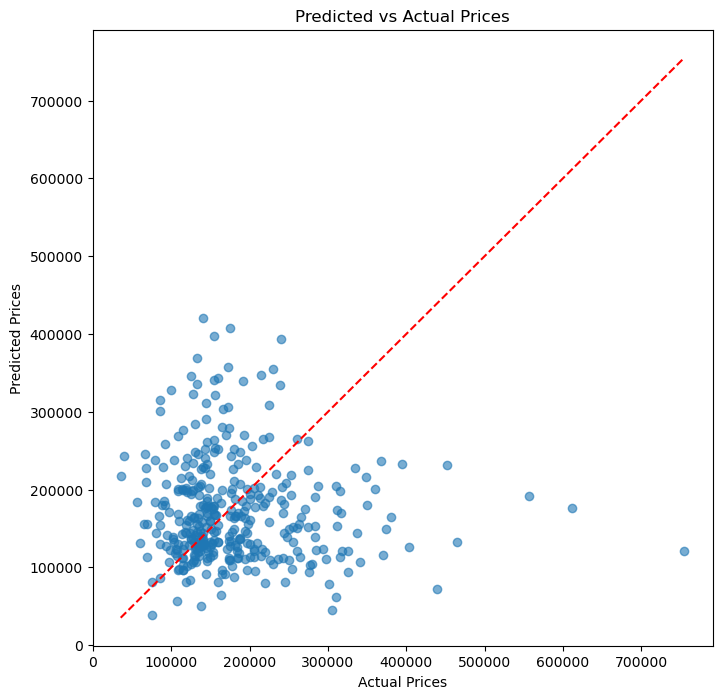

In [89]:
# Predicted vs Actual
plt.figure(figsize=(8, 8))
plt.scatter(test_y, test_pred, alpha=0.6)
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], color='red', linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual Prices")
plt.show()